# Fine-tune YOLO for Android UI Element Detection

**Goal:** train a screenshot-only UI element detector so the accessibility
auditor can still run when no XML view hierarchy is available (e.g. a raw
screenshot upload, or an app that blocks accessibility-tree extraction).

The XML view hierarchies we already have (from `data/data-masc`) are used
only to **generate training labels** (bounding boxes + classes). The model
itself never sees XML at inference time - it looks at pixels only.

**Data used:**
- `data/data-masc` - training/val/test (using the existing stratified splits
  in `data/data-masc/splits/`, unchanged).
- `data/data-rico-holdout` - held out entirely from training, used only for
  final generalization evaluation (zero-shot vs fine-tuned comparison).

**Target runtime:** a local machine with a CUDA GPU (developed against a
16GB-class card, e.g. an RTX 4060 Ti / T4-equivalent). Also runs a small
CPU-only smoke test (`LOCAL_MODE = True`) on ~20 images to catch pipeline
bugs before committing to a full training run.

All data, checkpoints, and exports live under this repo's own local
filesystem - nothing is synced to or mounted from cloud storage. If your GPU
box is remote, just run Jupyter on it directly (or over SSH port-forwarding)
rather than adapting this notebook to a specific cloud runtime.

Run cells top-to-bottom. Every code cell is independently re-runnable and
prints a success/failure summary - nothing fails silently.

## 0. Environment setup

Checks that `ultralytics` and the other packages this notebook needs are
importable, and installs anything missing with pip (quietly). Nothing is
mounted or downloaded here beyond those Python packages - no cloud storage
involved.

In [2]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = [
    ("ultralytics", "ultralytics>=8.3,<9"),
    ("huggingface_hub", "huggingface_hub>=0.24"),
    ("PIL", "Pillow"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("lxml", "lxml>=5.2.0"),
]

missing = []
for import_name, pip_spec in REQUIRED_PACKAGES:
    try:
        importlib.import_module(import_name)
    except ImportError:
        missing.append(pip_spec)

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("All required packages already importable.")

import ultralytics  # noqa: E402
print(f"ultralytics {ultralytics.__version__}")

All required packages already importable.
ultralytics 8.4.104


## Config

Every path and hyperparameter used below lives in one place: `CFG`. Flip
`LOCAL_MODE` to `True` to run a fast smoke test on ~20 images (works on
CPU) - useful for catching bugs in the label-generation/dataset-building
logic before committing to a full training run; `False` runs the real
pipeline on the full split.

`REPO_ROOT` is auto-discovered by walking up from the notebook's working
directory looking for a folder that contains both `src/` and `data/` - this
works whether you launched Jupyter from the repo root or from `notebooks/`.
`OUTPUT_ROOT` is a local directory (`<repo>/runs/yolo_ui_detector` by
default) that holds the generated YOLO dataset, training checkpoints, and
exports - it's gitignored, so re-running the notebook never risks committing
large binaries.

In [3]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    return None


LOCAL_MODE = False  # <-- flip to False for the full training run

REPO_ROOT = find_repo_root(Path.cwd())
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find repo root (a directory containing both src/ and data/) "
        f"by walking up from {Path.cwd()}. Run this notebook from inside the repo."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# All generated dataset/checkpoint/export files live here - override to any
# local path (e.g. a larger disk) if REPO_ROOT is space-constrained.
OUTPUT_ROOT = REPO_ROOT / "runs" / "yolo_ui_detector"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DATA_ROOT = REPO_ROOT / "data"

CFG = {
    "local_mode": LOCAL_MODE,
    "repo_root": REPO_ROOT,
    "output_root": OUTPUT_ROOT,
    "data_root": DATA_ROOT,
    "masc_root": DATA_ROOT / "data-masc",
    "rico_root": DATA_ROOT / "data-rico-holdout",
    "splits_dir": DATA_ROOT / "data-masc" / "splits",
    "yolo_dataset_dir": OUTPUT_ROOT / "yolo_dataset",
    "rico_yolo_dataset_dir": OUTPUT_ROOT / "rico_yolo_dataset",
    "runs_dir": OUTPUT_ROOT / "runs",
    "export_dir": OUTPUT_ROOT / "export",
    "run_name": "yolo_ui_detector",

    # -- class taxonomy (order fixes the YOLO class index) --
    "class_names": [
        "text",
        "image",
        "icon",
        "button_labeled",
        "button_icon_only",
        "input_field",
        "checkbox_toggle",
        "tab_item",
        "list_item",
    ],

    # size threshold (dp) below which an ImageView is called an "icon"
    # rather than an "image" - see the classification cell for rationale.
    "icon_max_dp": 64,

    # -- training hyperparameters --
    "imgsz": 960,
    "epochs": 60,
    "patience": 10,
    "seed": 42,
    "batch_by_size": {"l": 8, "m": 8, "s": 16},
    "init_weights_mode": "auto",  # "auto" | "screen2ax" | "yolo11m" | "yolo11s"
    "min_instances_warn": 100,

    "local_smoke_n": 20,
}

for key in ("masc_root", "rico_root", "splits_dir"):
    print(f"{key:22s} -> {CFG[key]} (exists: {CFG[key].exists()})")
print(f"{'output_root':22s} -> {OUTPUT_ROOT}")
print(f"{'LOCAL_MODE':22s} -> {LOCAL_MODE}")

masc_root              -> d:\New folder\agentic-accessibility-auditor\data\data-masc (exists: True)
rico_root              -> d:\New folder\agentic-accessibility-auditor\data\data-rico-holdout (exists: True)
splits_dir             -> d:\New folder\agentic-accessibility-auditor\data\data-masc\splits (exists: True)
output_root            -> d:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector
LOCAL_MODE             -> False


## Verify the data layout matches what this notebook assumes

Before touching any parsing logic, confirm the directories/splits actually
look the way the rest of the notebook expects. This is cheap and catches a
misconfigured `DATA_ROOT` immediately instead of 20 minutes into label
generation.

In [4]:
import csv

masc_root = CFG["masc_root"]
splits_dir = CFG["splits_dir"]

checks = {
    "data-masc/screenshots": masc_root / "screenshots",
    "data-masc/xml": masc_root / "xml",
    "data-masc/splits/train.csv": splits_dir / "train.csv",
    "data-masc/splits/val.csv": splits_dir / "val.csv",
    "data-masc/splits/test.csv": splits_dir / "test.csv",
}

ok = True
for label, path in checks.items():
    exists = path.exists()
    ok &= exists
    print(f"[{'OK' if exists else 'MISSING'}] {label} -> {path}")

if not ok:
    raise FileNotFoundError(
        "One or more required data-masc paths are missing under DATA_ROOT "
        f"({DATA_ROOT}). Check that data-masc is present in this repo's data/ dir."
    )

for split_name in ("train", "val", "test"):
    with open(splits_dir / f"{split_name}.csv", newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    print(f"{split_name}: {len(rows)} rows, columns={list(rows[0].keys())}")

rico_screens = CFG["rico_root"] / "screenshots"
rico_xml = CFG["rico_root"] / "xml"
rico_available = rico_screens.is_dir() and any(rico_screens.rglob("*.jpg"))
print()
print(f"data-rico-holdout screenshots present: {rico_available}")
if not rico_available:
    print(
        "NOTE: data-rico-holdout screenshots/xml are not present under DATA_ROOT "
        "(they're gitignored - only manifest CSVs + a partial parsed/ cache ship "
        "with the repo). The holdout evaluation cells later in this notebook will "
        "detect this and skip gracefully with a warning. Sync the full "
        "data-rico-holdout (screenshots/ + xml/) into DATA_ROOT to run them for real."
    )
CFG["rico_available"] = rico_available

[OK] data-masc/screenshots -> d:\New folder\agentic-accessibility-auditor\data\data-masc\screenshots
[OK] data-masc/xml -> d:\New folder\agentic-accessibility-auditor\data\data-masc\xml
[OK] data-masc/splits/train.csv -> d:\New folder\agentic-accessibility-auditor\data\data-masc\splits\train.csv
[OK] data-masc/splits/val.csv -> d:\New folder\agentic-accessibility-auditor\data\data-masc\splits\val.csv
[OK] data-masc/splits/test.csv -> d:\New folder\agentic-accessibility-auditor\data\data-masc\splits\test.csv
train: 4943 rows, columns=['screen_id', 'class', 'category', 'image_path', 'xml_path']
val: 1056 rows, columns=['screen_id', 'class', 'category', 'image_path', 'xml_path']
test: 1069 rows, columns=['screen_id', 'class', 'category', 'image_path', 'xml_path']

data-rico-holdout screenshots present: True


## Inspect a couple of real XML files before writing any parsing logic

The repo already has a hybrid XML parser at `src/parser.py` (`parse_ui_xml`,
`build_screen_document`) that handles both real UIAutomator dumps and the
MASC dataset's own `<wrapper>`-nested format, and that already computes a
`visible` flag per component (`visibility="gone"` / `visible-to-user="False"`
in the source XML). We reuse it directly instead of re-parsing XML by hand -
re-implementing bounds extraction would just reproduce (and risk
regressing) logic that's already been hardened against this dataset's
quirks (see the long docstring on `_parse_masc_bounds` in `src/parser.py`
about inverted/local-vs-absolute bounds candidates).

This cell parses two sample screens and prints what actually comes back, so
the label-generation logic below is built against reality, not assumptions.

In [5]:
from src.parser import build_screen_document

sample_rows = [
    {"category": "home", "screen_id": "10053"},
    {"category": "chat", "screen_id": "492"},
]

for row in sample_rows:
    xml_path = masc_root / "xml" / row["category"] / f"{row['screen_id']}.xml"
    if not xml_path.exists():
        print(f"[skip] {xml_path} not found")
        continue
    doc = build_screen_document(xml_path, masc_root / "xml", masc_root)
    comps = doc["components"]
    n_visible = sum(1 for c in comps if c.get("visible", True))
    print(f"=== {row['category']}/{row['screen_id']} ===")
    print(f"  components: {len(comps)} ({n_visible} visible)")
    print(f"  device_info: {doc['device_info']}")
    clickable_with_text = [c for c in comps if c["clickable"] and c["text"]]
    if clickable_with_text:
        c = clickable_with_text[0]
        print(f"  sample clickable+text component: class={c['class']!r} text={c['text']!r} bounds={c['bounds']}")

    # device_info's width/height is itself derived from the union of every
    # component's bounds when the XML root has no bounds attribute (true
    # here - see src.parser._extract_device_info). If any sibling sits
    # off-canvas (e.g. an inactive ViewPager page), that union - and hence
    # device_info - is inflated well past the real screen width. Compare it
    # against the max x/y among components anchored at the origin (which
    # real full-screen root containers always are) to see whether that's
    # happening on this sample:
    max_right_all = max((c["bounds"][2] for c in comps), default=0)
    max_right_origin = max((c["bounds"][2] for c in comps if c["bounds"][0] == 0 and c["bounds"][1] == 0), default=0)
    if max_right_all != max_right_origin:
        print(f"  NOTE: max right-bound across ALL components = {max_right_all}, "
              f"but max right-bound among origin-anchored (real screen) components = {max_right_origin}. "
              "device_info.width_px would be inflated here - label generation uses the origin-anchored value instead.")
    print()

=== home/10053 ===
  components: 68 (18 visible)
  device_info: {'dpi': 160, 'width_px': 4320, 'height_px': 2560}
  sample clickable+text component: class='android.widget.Button' text='Subscribe' bounds=[440, 417, 1000, 585]
  NOTE: max right-bound across ALL components = 4320, but max right-bound among origin-anchored (real screen) components = 1440. device_info.width_px would be inflated here - label generation uses the origin-anchored value instead.

=== chat/492 ===
  components: 58 (33 visible)
  device_info: {'dpi': 160, 'width_px': 1440, 'height_px': 2560}
  sample clickable+text component: class='android.support.v7.widget.AppCompatTextView' text='Add URL' bounds=[1192, 89, 1415, 247]



## 1. Label generation: XML -> YOLO format

### Class taxonomy

Nine accessibility-relevant classes:

| class | meaning |
|---|---|
| `text` | non-interactive rendered text (labels, body copy, headings) |
| `image` | non-interactive image/illustration/photo |
| `icon` | small non-interactive glyph/icon (≤ `icon_max_dp` on its longest side) |
| `button_labeled` | a clickable control that has a visible text label or content-description |
| `button_icon_only` | a clickable control with **no** text/content-description |
| `input_field` | text entry, dropdown, search box, slider |
| `checkbox_toggle` | checkbox / radio button / switch / toggle |
| `tab_item` | an individual tab / bottom-nav item |
| `list_item` | a direct child row of a scrolling list/grid/pager container |

`button_labeled` vs `button_icon_only` is derived, not hand-labeled: **any
clickable node is `button_labeled` if it (or its Android accessibility
metadata) carries text or a `content-desc`, otherwise `button_icon_only`.**
This mirrors how a screen reader actually decides whether a control is
announced with a name or just "button".

The Android-class -> base-type mapping below is a plain Python list you can
edit directly - it's intentionally not buried in a function. Order matters:
it's checked top-to-bottom and the first substring match on the component's
`class` string wins (so more specific names like `ToggleButton` must be
listed before the generic `Button` they'd otherwise also match).

In [6]:
# Ordered (substring, base_type) rules. `class` is the raw Android class name
# from the XML (e.g. "android.widget.EditText", "androidx.appcompat.widget.SwitchCompat").
# base_type of "__button__" / "__image_or_icon__" / "__text_or_button__" are
# resolved dynamically below (they depend on clickable/text, not just class name).
CLASS_RULES = [
    ("CheckBox", "checkbox_toggle"),
    ("RadioButton", "checkbox_toggle"),
    ("ToggleButton", "checkbox_toggle"),
    ("Switch", "checkbox_toggle"),            # covers Switch and SwitchCompat
    ("AutoCompleteTextView", "input_field"),
    ("EditText", "input_field"),
    ("SearchView", "input_field"),
    ("Spinner", "input_field"),
    ("SeekBar", "input_field"),
    ("TabItem", "tab_item"),
    ("TabLayout$Tab", "tab_item"),
    ("BottomNavigationItemView", "tab_item"),
    ("NavigationRailItemView", "tab_item"),
    ("ImageButton", "__button__"),
    ("Button", "__button__"),                 # generic android.widget.Button
    ("ImageView", "__image_or_icon__"),
    ("TextView", "__text_or_button__"),
]

# Direct children of these container classes are treated as list_item
# (one repeated row of a scrolling collection), overriding whatever the
# child's own class would otherwise map to.
LIST_CONTAINER_MARKERS = ("RecyclerView", "ListView", "GridView", "ViewPager")
LIST_RESOURCE_ID_MARKERS = ("list_item", "row_item", "item_row")


def _px_to_dp(px, dpi):
    return px * 160.0 / max(dpi, 1)


def classify_image_size(component, dpi, icon_max_dp):
    left, top, right, bottom = component["bounds"]
    w_dp = _px_to_dp(abs(right - left), dpi)
    h_dp = _px_to_dp(abs(bottom - top), dpi)
    return "icon" if max(w_dp, h_dp) <= icon_max_dp else "image"


def classify_component(component, parent_by_id, dpi, icon_max_dp=CFG["icon_max_dp"]):
    """Map one parsed XML component to a YOLO class name, or None to drop it
    (containers/layouts and other non-interactive, non-content nodes aren't
    detection targets)."""
    cls = component["class"]
    text = (component.get("text") or "").strip()
    content_desc = (component.get("content_desc") or "").strip()
    clickable = bool(component.get("clickable"))
    resource_id = (component.get("resource_id") or "").lower()
    has_label = bool(text) or bool(content_desc)

    parent = parent_by_id.get(component.get("parent_id"))
    if parent is not None and any(marker in parent["class"] for marker in LIST_CONTAINER_MARKERS):
        return "list_item"
    if any(marker in resource_id for marker in LIST_RESOURCE_ID_MARKERS):
        return "list_item"

    for substring, base in CLASS_RULES:
        if substring not in cls:
            continue
        if base == "__button__":
            if not clickable:
                return None
            return "button_labeled" if has_label else "button_icon_only"
        if base == "__image_or_icon__":
            return classify_image_size(component, dpi, icon_max_dp)
        if base == "__text_or_button__":
            if clickable:
                return "button_labeled" if has_label else "button_icon_only"
            return "text" if text else None
        return base

    # Fallback: any other clickable leaf node the rules above didn't catch.
    if clickable:
        return "button_labeled" if has_label else "button_icon_only"
    return None


print("Loaded classify_component(). Class taxonomy:", CFG["class_names"])

Loaded classify_component(). Class taxonomy: ['text', 'image', 'icon', 'button_labeled', 'button_icon_only', 'input_field', 'checkbox_toggle', 'tab_item', 'list_item']


### Filtering and coordinate scaling

Four things reliably corrupt XML-derived boxes if left unfiltered (this bit
the accessibility-rule pipeline before - see
`scripts/compare_visibility_filter_impact.py` and `src/rules.py`'s
`check()`, which drops hidden components for exactly this reason):

1. **Hidden nodes** - `visibility="gone"` / `visible-to-user="False"`. The
   parser already computes this as `component["visible"]`.
2. **Zero/negative-area boxes** - inverted or collapsed rects (common on
   `gone` elements whose absolute-position computation never ran, see the
   `_parse_masc_bounds` docstring in `src/parser.py`).
3. **Fully off-screen boxes** - MASC's `<wrapper>` bounds are captured in a
   virtual layout canvas, not the visible screen. A `ViewPager`'s inactive
   pages, for instance, sit laid out at x-offsets far beyond the screen
   width (verified above: an ImageView with bounds `[2968, ...]` while the
   screen is 1440px wide - that's the *next* onboarding page, currently
   scrolled off). We clip to the image canvas and drop anything that
   clips to zero area.
4. **Duplicated bounds** - the same class+box appearing twice for a screen
   (e.g. nested wrapper containers with identical geometry after taxonomy
   mapping collapses them to the same class).

**Coordinate scaling:** XML bounds are captured in the device's own pixel
space (e.g. `1440x2560`), which does not always match the actual screenshot
file's pixel dimensions. We read the real image size with PIL and rescale
bounds by `(img_w / xml_canvas_w, img_h / xml_canvas_h)` before normalizing,
then assert every emitted box is within `[0, 1]`.

In [7]:
from collections import Counter

from PIL import Image


def _xml_canvas_size(device_info, components):
    # NOT device_info first: src.parser._extract_device_info falls back to the
    # union of *every* component's bounds when the XML root carries no bounds
    # attribute of its own - true for effectively all MASC/UIAutomator dumps
    # (confirmed empirically: <hierarchy> never has a bounds attr here). That
    # union gets polluted by off-canvas siblings - e.g. a ViewPager's inactive
    # pages are laid out at x-offsets past the real screen edge (see the
    # off-screen filtering note above: an onboarding page observed at
    # bounds starting x=2880 on a 1440px-wide screen). Trusting that number
    # as the scaling denominator would squash every box on the screen into a
    # fraction of the real image. Root containers that actually cover the
    # visible screen are anchored at the origin, so restricting the union to
    # components with bounds starting at (0, 0) reliably isolates the real
    # canvas size instead.
    origin_anchored = [c for c in components if c["bounds"][0] == 0 and c["bounds"][1] == 0]
    w = max((c["bounds"][2] for c in origin_anchored), default=0)
    h = max((c["bounds"][3] for c in origin_anchored), default=0)
    if w > 0 and h > 0:
        return w, h
    w = device_info.get("width_px", 0) or 0
    h = device_info.get("height_px", 0) or 0
    if w > 0 and h > 0:
        return w, h
    # Last resort: union of every component's bounds (may be inflated - see above).
    w = max((c["bounds"][2] for c in components), default=0)
    h = max((c["bounds"][3] for c in components), default=0)
    return w, h


def convert_screen_to_yolo_labels(xml_path, image_path, dataset_root, class_names, icon_max_dp):
    """Parse one XML file and return (label_lines, drop_counts, class_counts).

    label_lines: list of 'class_idx cx cy w h\n' strings, already normalized
    and clipped to [0, 1].
    drop_counts: Counter keyed by drop reason, for the CRITICAL filtering
    this dataset needs (see markdown above).
    """
    from src.parser import build_screen_document

    drop_counts = Counter()
    class_counts = Counter()
    label_lines = []

    doc = build_screen_document(Path(xml_path), Path(xml_path).parent.parent, dataset_root)
    components = doc["components"]
    device_info = doc["device_info"]
    dpi = device_info.get("dpi", 160)

    with Image.open(image_path) as im:
        img_w, img_h = im.size

    xml_w, xml_h = _xml_canvas_size(device_info, components)
    if xml_w <= 0 or xml_h <= 0:
        drop_counts["unusable_canvas"] += len(components)
        return [], drop_counts, class_counts

    scale_x = img_w / xml_w
    scale_y = img_h / xml_h

    parent_by_id = {c["component_id"]: c for c in components}
    seen_boxes = set()

    for component in components:
        if not component.get("visible", True):
            drop_counts["hidden_visibility"] += 1
            continue

        left, top, right, bottom = component["bounds"]
        raw_w, raw_h = right - left, bottom - top
        if raw_w <= 0 or raw_h <= 0:
            drop_counts["zero_or_negative_area"] += 1
            continue

        label = classify_component(component, parent_by_id, dpi, icon_max_dp)
        if label is None:
            drop_counts["unmapped_class"] += 1
            continue

        sx_left, sx_right = left * scale_x, right * scale_x
        sy_top, sy_bottom = top * scale_y, bottom * scale_y
        clipped_left = max(0.0, min(sx_left, img_w))
        clipped_right = max(0.0, min(sx_right, img_w))
        clipped_top = max(0.0, min(sy_top, img_h))
        clipped_bottom = max(0.0, min(sy_bottom, img_h))

        if clipped_right <= clipped_left or clipped_bottom <= clipped_top:
            drop_counts["off_screen"] += 1
            continue

        cx = (clipped_left + clipped_right) / 2 / img_w
        cy = (clipped_top + clipped_bottom) / 2 / img_h
        w = (clipped_right - clipped_left) / img_w
        h = (clipped_bottom - clipped_top) / img_h

        dedupe_key = (label, round(cx, 4), round(cy, 4), round(w, 4), round(h, 4))
        if dedupe_key in seen_boxes:
            drop_counts["duplicate_bounds"] += 1
            continue
        seen_boxes.add(dedupe_key)

        for v in (cx, cy, w, h):
            assert -1e-6 <= v <= 1 + 1e-6, f"box out of [0,1]: {dedupe_key}"
        cx, cy, w, h = (min(max(v, 0.0), 1.0) for v in (cx, cy, w, h))

        class_idx = class_names.index(label)
        label_lines.append(f"{class_idx} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        drop_counts["kept"] += 1
        class_counts[label] += 1

    return label_lines, drop_counts, class_counts


print("Loaded convert_screen_to_yolo_labels().")

Loaded convert_screen_to_yolo_labels().


## Build the YOLO dataset directory (mirrors the existing splits)

We use `data/data-masc/splits/{train,val,test}.csv` **as-is** - no new
random split is created. For each row we:
1. Generate YOLO labels for its XML file.
2. Link (or copy, if symlinks aren't available - e.g. Windows without
   developer mode) its screenshot into `yolo_dataset/images/<split>/`.
3. Write the label file into `yolo_dataset/labels/<split>/`.

Every row is counted as success or failure - the loop never fails silently.
In `LOCAL_MODE`, only the first `CFG['local_smoke_n']` rows of each split
are processed, to keep the smoke test fast.

In [8]:
import os
import shutil


def link_or_copy(src, dst):
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    try:
        os.symlink(os.path.abspath(src), dst)
    except (OSError, NotImplementedError):
        shutil.copy2(src, dst)


def read_split_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def build_yolo_split(split_name, rows, dataset_root, out_root, class_names, icon_max_dp, repo_root):
    images_dir = out_root / "images" / split_name
    labels_dir = out_root / "labels" / split_name
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    total_drop = Counter()
    total_class = Counter()
    n_ok, n_fail = 0, 0
    failures = []

    for row in rows:
        screen_id, category = row["screen_id"], row["category"]
        xml_path = repo_root / row["xml_path"]
        image_path = repo_root / row["image_path"]
        stem = f"{category}_{screen_id}"
        try:
            if not xml_path.exists() or not image_path.exists():
                raise FileNotFoundError(f"missing xml or image for {stem}")
            label_lines, drop_counts, class_counts = convert_screen_to_yolo_labels(
                xml_path, image_path, dataset_root, class_names, icon_max_dp
            )
            if not label_lines:
                raise ValueError(f"{stem}: zero usable boxes after filtering")

            (labels_dir / f"{stem}.txt").write_text("".join(label_lines), encoding="utf-8")
            link_or_copy(image_path, images_dir / f"{stem}{image_path.suffix}")

            total_drop.update(drop_counts)
            total_class.update(class_counts)
            n_ok += 1
        except Exception as exc:  # noqa: BLE001 - deliberately broad: never fail the batch silently
            n_fail += 1
            failures.append((stem, str(exc)))

    print(f"[{split_name}] ok={n_ok} fail={n_fail} total={len(rows)}")
    if failures:
        print(f"  first failures: {failures[:5]}")
    print(f"  drop reasons: {dict(total_drop)}")
    print(f"  class counts: {dict(total_class)}")
    return {"n_ok": n_ok, "n_fail": n_fail, "failures": failures, "drop": total_drop, "class_counts": total_class}


print("Loaded build_yolo_split().")

Loaded build_yolo_split().


In [9]:
split_results = {}
build_summaries = {}

for split_name in ("train", "val", "test"):
    rows = read_split_csv(CFG["splits_dir"] / f"{split_name}.csv")
    if CFG["local_mode"]:
        rows = rows[: CFG["local_smoke_n"]]
    split_results[split_name] = rows

for split_name, rows in split_results.items():
    build_summaries[split_name] = build_yolo_split(
        split_name,
        rows,
        CFG["masc_root"],
        CFG["yolo_dataset_dir"],
        CFG["class_names"],
        CFG["icon_max_dp"],
        CFG["repo_root"],
    )

overall_fail = sum(s["n_fail"] for s in build_summaries.values())
print()
print(f"TOTAL failures across all splits: {overall_fail}")

[train] ok=4942 fail=1 total=4943
  first failures: [('welcome_68599', 'welcome_68599: zero usable boxes after filtering')]
  drop reasons: {'unmapped_class': 105253, 'hidden_visibility': 241870, 'kept': 95280, 'duplicate_bounds': 1867, 'off_screen': 652, 'zero_or_negative_area': 36}
  class counts: {'button_icon_only': 11926, 'text': 31611, 'list_item': 15856, 'image': 15820, 'input_field': 2652, 'button_labeled': 12718, 'tab_item': 633, 'icon': 1864, 'checkbox_toggle': 2200}
[val] ok=1054 fail=2 total=1056
  first failures: [('login_63858', 'login_63858: zero usable boxes after filtering'), ('welcome_39771', 'welcome_39771: zero usable boxes after filtering')]
  drop reasons: {'unmapped_class': 22177, 'hidden_visibility': 51613, 'kept': 20476, 'duplicate_bounds': 466, 'off_screen': 110, 'zero_or_negative_area': 1}
  class counts: {'button_icon_only': 2658, 'text': 6791, 'list_item': 3183, 'image': 3430, 'button_labeled': 2884, 'icon': 453, 'input_field': 511, 'checkbox_toggle': 463, 

### Write the Ultralytics `dataset.yaml`

In [10]:
dataset_yaml_path = CFG["yolo_dataset_dir"] / "dataset.yaml"
yaml_lines = [
    f"path: {CFG['yolo_dataset_dir'].as_posix()}\n",
    "train: images/train\n",
    "val: images/val\n",
    "test: images/test\n",
    "names:\n",
]
for idx, name in enumerate(CFG["class_names"]):
    yaml_lines.append(f"  {idx}: {name}\n")

dataset_yaml_path.write_text("".join(yaml_lines), encoding="utf-8")
print(f"Wrote {dataset_yaml_path}")
print(dataset_yaml_path.read_text(encoding="utf-8"))

Wrote d:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector\yolo_dataset\dataset.yaml
path: d:/New folder/agentic-accessibility-auditor/runs/yolo_ui_detector/yolo_dataset
train: images/train
val: images/val
test: images/test
names:
  0: text
  1: image
  2: icon
  3: button_labeled
  4: button_icon_only
  5: input_field
  6: checkbox_toggle
  7: tab_item
  8: list_item



## 2. Sanity-check cell (mandatory before training)

Render 12 random training screenshots with their generated boxes overlaid,
color-coded by class. **If this looks wrong, everything downstream is
wrong** - do not proceed to training until these boxes visibly line up with
real UI elements.

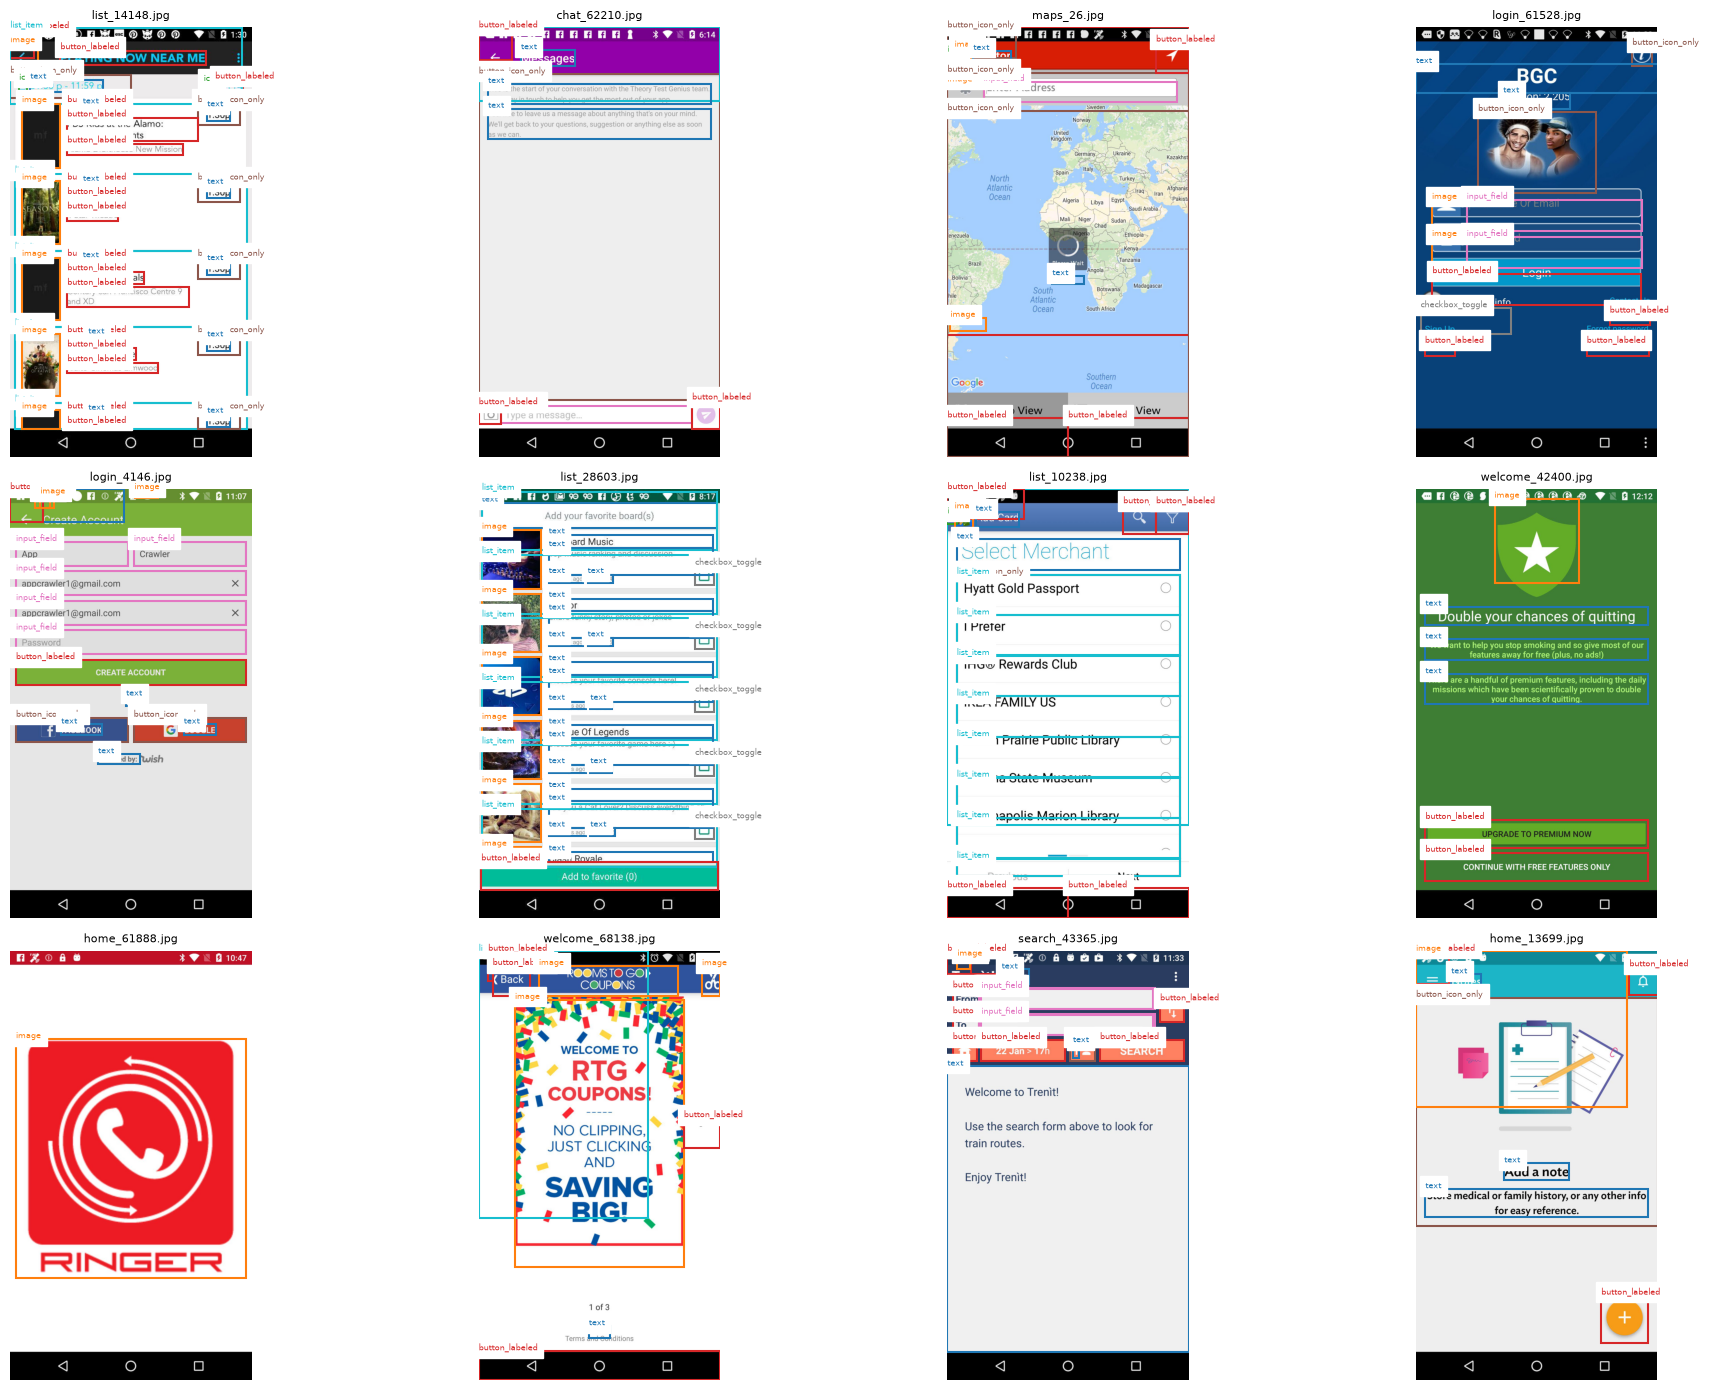

In [11]:
import random

import matplotlib
import matplotlib.patches as patches
import matplotlib.pyplot as plt

%matplotlib inline

CLASS_COLORS = matplotlib.colormaps["tab10"].resampled(len(CFG["class_names"]))


def draw_boxes_on_ax(ax, image_path, label_path, class_names):
    with Image.open(image_path) as im:
        ax.imshow(im)
        img_w, img_h = im.size
    if not label_path.exists():
        ax.set_title(f"{image_path.name} (no labels)")
        return
    for line in label_path.read_text(encoding="utf-8").splitlines():
        cls_idx, cx, cy, w, h = line.split()
        cls_idx, cx, cy, w, h = int(cls_idx), float(cx), float(cy), float(w), float(h)
        left = (cx - w / 2) * img_w
        top = (cy - h / 2) * img_h
        color = CLASS_COLORS(cls_idx)
        rect = patches.Rectangle((left, top), w * img_w, h * img_h, linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(left, max(top - 4, 0), class_names[cls_idx], color=color, fontsize=6, backgroundcolor="white")
    ax.set_title(image_path.name, fontsize=8)
    ax.axis("off")


images_dir = CFG["yolo_dataset_dir"] / "images" / "train"
labels_dir = CFG["yolo_dataset_dir"] / "labels" / "train"
all_images = sorted(images_dir.glob("*"))
assert all_images, f"No images found in {images_dir} - run the label-generation cells above first."

sample = random.Random(CFG["seed"]).sample(all_images, k=min(12, len(all_images)))
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for ax, image_path in zip(axes.ravel(), sample):
    label_path = labels_dir / f"{image_path.stem}.txt"
    draw_boxes_on_ax(ax, image_path, label_path, CFG["class_names"])
for ax in axes.ravel()[len(sample):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
train_class_counts = build_summaries["train"]["class_counts"]
print(f"{'class':<20}{'instances':>10}")
print("-" * 30)
for name in CFG["class_names"]:
    n = train_class_counts.get(name, 0)
    flag = "  <-- LOW (<%d)" % CFG["min_instances_warn"] if n < CFG["min_instances_warn"] else ""
    print(f"{name:<20}{n:>10}{flag}")

low_classes = [n for n in CFG["class_names"] if train_class_counts.get(n, 0) < CFG["min_instances_warn"]]
if low_classes:
    print()
    print(f"WARNING: classes with fewer than {CFG['min_instances_warn']} training instances: {low_classes}")
    if CFG["local_mode"]:
        print("(expected in LOCAL_MODE - it only samples a handful of screens; re-check on the full split.)")

class                instances
------------------------------
text                     31611
image                    15820
icon                      1864
button_labeled           12718
button_icon_only         11926
input_field               2652
checkbox_toggle           2200
tab_item                   633
list_item                15856


## 3. Training

### Base weights

We prefer initializing from MacPaw's Screen2AX UI-element detector
(`macpaw-research/yolov11l-ui-elements-detection` on Hugging Face) since
it's already tuned to detect UI elements rather than generic COCO objects -
that head start matters a lot with our per-class instance counts. Its
backbone is YOLO11-**l**, which may be too heavy to train comfortably at
`imgsz=960` on a 16GB-class GPU alongside batch normalization statistics and
gradients; in that case we fall back to COCO-pretrained `yolo11m` or
`yolo11s`. `CFG['init_weights_mode']` controls this (`"auto"` decides from
GPU memory).

In [13]:
import torch
from ultralytics import YOLO


def gpu_total_mem_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)


def load_screen2ax_weights():
    from huggingface_hub import HfApi, hf_hub_download

    repo_id = "macpaw-research/yolov11l-ui-elements-detection"
    files = HfApi().list_repo_files(repo_id)
    pt_files = [f for f in files if f.endswith(".pt")]
    if not pt_files:
        raise FileNotFoundError(f"No .pt weights found in {repo_id}")
    return hf_hub_download(repo_id=repo_id, filename=pt_files[0])


def resolve_init_weights(mode, mem_gb):
    if mode == "yolo11s":
        return "yolo11s.pt", "s", "yolo11s (COCO, forced by config)"
    if mode == "yolo11m":
        return "yolo11m.pt", "m", "yolo11m (COCO, forced by config)"
    if mode in ("auto", "screen2ax"):
        if mem_gb == 0 or mem_gb < 10:
            print(f"GPU memory {mem_gb:.1f}GB too small (or no GPU) for the 'l' Screen2AX backbone - using yolo11s COCO weights.")
            return "yolo11s.pt", "s", "yolo11s (COCO, no/low GPU fallback)"
        try:
            path = load_screen2ax_weights()
            return path, "l", "macpaw-research/yolov11l-ui-elements-detection (Screen2AX)"
        except Exception as exc:  # noqa: BLE001
            print(f"Could not fetch Screen2AX weights ({exc}); falling back to yolo11m COCO weights.")
            return "yolo11m.pt", "m", "yolo11m (COCO, Screen2AX download failed)"
    raise ValueError(f"Unknown init_weights_mode: {mode}")


mem_gb = gpu_total_mem_gb()
print(f"GPU memory: {mem_gb:.1f}GB" if mem_gb else "No GPU detected (CPU run).")

init_weights_path, model_size, init_description = resolve_init_weights(CFG["init_weights_mode"], mem_gb)
print(f"Using init weights: {init_description}")

base_model = YOLO(init_weights_path)

GPU memory: 20.0GB


c:\Users\Lab\miniconda3\envs\UAV_2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using init weights: macpaw-research/yolov11l-ui-elements-detection (Screen2AX)


### Training configuration

- `imgsz=960` - tall mobile screenshots need more vertical resolution than
  the usual 640 default.
- Batch size auto-tuned from `CFG['batch_by_size']` by model size (8 for
  m/l, 16 for s), halved automatically (down to a floor of 2) if a CUDA
  out-of-memory error is hit.
- 60 epochs, cosine LR, early-stopping patience 10.
- Standard mosaic + horizontal flip augmentation, but **vertical flip
  (`flipud`) and heavy rotation (`degrees`) are disabled** - a UI screenshot
  is never upside down or rotated, so training on flipped/rotated UIs would
  teach the model layouts that never occur in practice.
- **Resume-from-checkpoint:** if `OUTPUT_ROOT/runs/<run_name>/weights/last.pt`
  already exists (e.g. the process was killed or the machine rebooted
  mid-run last time), we resume training from it instead of starting over.
  `best.pt`/`last.pt` are saved every epoch regardless of `save_period`,
  which is what makes this work; `save_period` only controls extra
  per-epoch snapshot copies (`epoch<N>.pt`), which we keep off (`-1`)
  since they aren't needed for resume and burn disk space fast.

In [14]:
run_dir = CFG["runs_dir"] / CFG["run_name"]
last_ckpt = run_dir / "weights" / "last.pt"
resume = last_ckpt.exists()

if resume:
    print(f"Found existing checkpoint at {last_ckpt} - resuming training from it.")
    train_model = YOLO(str(last_ckpt))
else:
    print("No existing checkpoint found - starting a fresh run.")
    train_model = base_model

batch = CFG["batch_by_size"][model_size]
epochs = 1 if CFG["local_mode"] else CFG["epochs"]

train_kwargs = dict(
    data=str(dataset_yaml_path),
    imgsz=CFG["imgsz"],
    epochs=epochs,
    patience=CFG["patience"],
    batch=batch,
    cos_lr=True,
    mosaic=1.0,
    fliplr=0.5,
    flipud=0.0,   # UIs are never upside down
    degrees=0.0,  # UIs are never rotated
    project=str(CFG["runs_dir"]),
    name=CFG["run_name"],
    exist_ok=True,
    save=True,
    save_period=-1,  # last.pt/best.pt still save every epoch; -1 skips the extra per-epoch snapshot copies
    seed=CFG["seed"],
    resume=resume,
    plots=True,
)

print(f"Training with batch={batch}, epochs={epochs}, resume={resume}")
print(train_kwargs)

Found existing checkpoint at d:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector\runs\yolo_ui_detector\weights\last.pt - resuming training from it.
Training with batch=8, epochs=60, resume=True
{'data': 'd:\\New folder\\agentic-accessibility-auditor\\runs\\yolo_ui_detector\\yolo_dataset\\dataset.yaml', 'imgsz': 960, 'epochs': 60, 'patience': 10, 'batch': 8, 'cos_lr': True, 'mosaic': 1.0, 'fliplr': 0.5, 'flipud': 0.0, 'degrees': 0.0, 'project': 'd:\\New folder\\agentic-accessibility-auditor\\runs\\yolo_ui_detector\\runs', 'name': 'yolo_ui_detector', 'exist_ok': True, 'save': True, 'save_period': -1, 'seed': 42, 'resume': True, 'plots': True}


### Train

This is the one cell allowed to run longer than 5 minutes. If a CUDA OOM
error is hit, batch size is halved (down to a floor of 2) and the attempt
retried automatically.

In [15]:
current_batch = batch
train_results = None
attempt_kwargs = dict(train_kwargs)

while True:
    attempt_kwargs["batch"] = current_batch
    try:
        train_results = train_model.train(**attempt_kwargs)
        break
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        current_batch = max(2, current_batch // 2)
        if current_batch == attempt_kwargs["batch"]:
            raise
        print(f"CUDA OOM - retrying with batch={current_batch}")
        attempt_kwargs["resume"] = False  # a fresh attempt at a new batch size isn't a resume

best_pt = run_dir / "weights" / "best.pt"
last_pt = run_dir / "weights" / "last.pt"
print(f"best.pt -> {best_pt} (exists: {best_pt.exists()})")
print(f"last.pt -> {last_pt} (exists: {last_pt.exists()})")

New https://pypi.org/project/ultralytics/8.4.107 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.104  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20474MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector\yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, l

### Training curves

Ultralytics already logs a `results.csv` per run; plot loss and mAP from it.

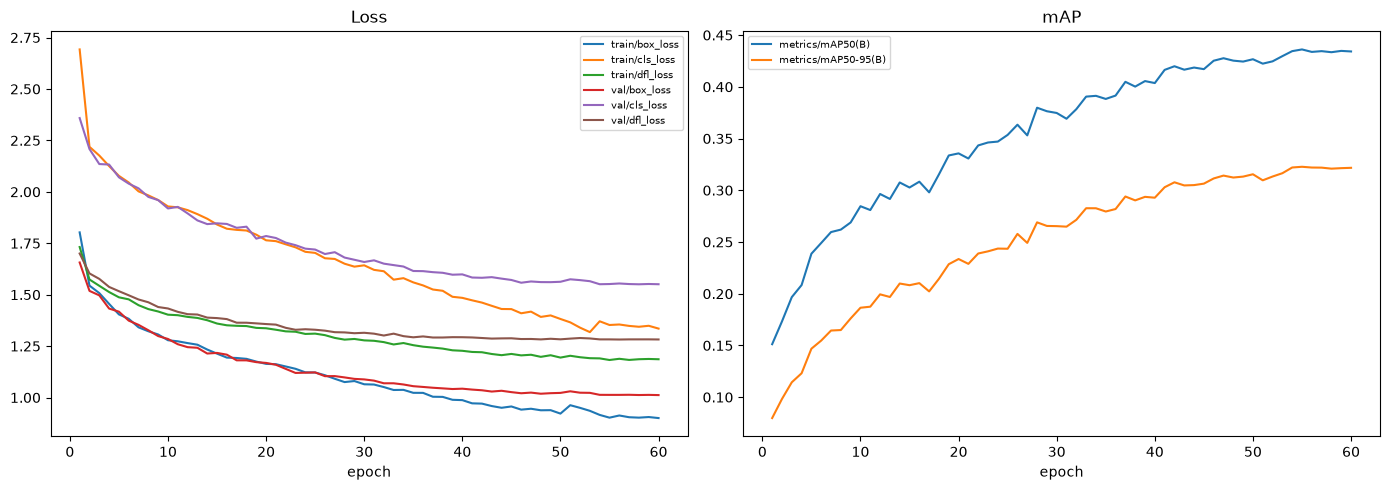

Saved d:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector\training_curves.png


In [16]:
import pandas as pd

results_csv = run_dir / "results.csv"
if not results_csv.exists():
    print(f"No results.csv at {results_csv} yet - skipping curve plot.")
else:
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    loss_cols = [c for c in df.columns if c.endswith("loss")]
    for c in loss_cols:
        axes[0].plot(df["epoch"], df[c], label=c)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend(fontsize=7)

    map_cols = [c for c in df.columns if "mAP" in c]
    for c in map_cols:
        axes[1].plot(df["epoch"], df[c], label=c)
    axes[1].set_title("mAP")
    axes[1].set_xlabel("epoch")
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    curve_path = CFG["output_root"] / "training_curves.png"
    plt.savefig(curve_path, dpi=150)
    plt.show()
    print(f"Saved {curve_path}")

## 4. Evaluation

### mAP50 / mAP50-95 on the test split (overall and per-class)

In [17]:
eval_model = YOLO(str(best_pt)) if best_pt.exists() else train_model
test_results = eval_model.val(data=str(dataset_yaml_path), split="test", imgsz=CFG["imgsz"])

print(f"Overall mAP50:    {test_results.box.map50:.4f}")
print(f"Overall mAP50-95: {test_results.box.map:.4f}")
print()
print(f"{'class':<20}{'mAP50-95':>10}")
print("-" * 30)
names = test_results.names
for idx, class_map in enumerate(test_results.box.maps):
    print(f"{names.get(idx, str(idx)):<20}{class_map:>10.4f}")

Ultralytics 8.4.104  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20474MiB)
YOLO11l summary (fused): 191 layers, 25,286,251 parameters, 0 gradients, 86.6 GFLOPs
WARNING val: Slow image access detected (ping: 0.00.0 ms, read: 18.113.9 MB/s, size: 134.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning D:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector\yolo_dataset\labels\test... 1068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1068/1068 764.5it/s 1.4s0.1s
val: New cache created: D:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector\yolo_dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 3.4it/s 19.4s0.3s
                   all       1068      20556      0.513      0.447      0.428      0.318
                  text        947       68

### Zero-shot vs fine-tuned on `data-rico-holdout`

`data-rico-holdout` was never used for training. We build a YOLO-format
copy of it (same conversion function as above) and evaluate **both** the
original base weights (zero-shot) and our fine-tuned `best.pt` on it, to
measure how much the fine-tune actually helps on genuinely unseen apps.

This cell checks `CFG['rico_available']` first and skips with a clear
message rather than crashing if the holdout images/xml aren't present
locally (see the layout-verification cell above).

In [18]:
if not CFG["rico_available"]:
    print("Skipping rico-holdout evaluation: screenshots/xml not found under DATA_ROOT.")
    print("Sync data-rico-holdout/{screenshots,xml} into DATA_ROOT to run this for real.")
else:
    rico_rows = []
    with open(CFG["rico_root"] / "manifest" / "screens.csv", newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            rico_rows.append({
                "screen_id": row["screen_id"],
                "category": row["category"],
                "xml_path": row["xml_path"],
                "image_path": row["screenshots_path"],
            })
    if CFG["local_mode"]:
        rico_rows = rico_rows[: CFG["local_smoke_n"]]

    rico_summary = build_yolo_split(
        "test", rico_rows, CFG["rico_root"], CFG["rico_yolo_dataset_dir"],
        CFG["class_names"], CFG["icon_max_dp"], CFG["repo_root"],
    )

    rico_yaml_path = CFG["rico_yolo_dataset_dir"] / "dataset.yaml"
    yaml_lines = [
        f"path: {CFG['rico_yolo_dataset_dir'].as_posix()}\n",
        "train: images/test\n",
        "val: images/test\n",
        "test: images/test\n",
        "names:\n",
    ]
    for idx, name in enumerate(CFG["class_names"]):
        yaml_lines.append(f"  {idx}: {name}\n")
    rico_yaml_path.write_text("".join(yaml_lines), encoding="utf-8")

    # single_cls=True: the pretrained base weights use a different, incompatible
    # class taxonomy (Screen2AX's 5 macOS AX roles, or COCO's 80 classes, depending on
    # which fallback resolve_init_weights picked) than our 9-class dataset.yaml, so
    # per-class validation indexes out of bounds in ultralytics' confusion matrix.
    # Falling back to class-agnostic eval measures the only thing that is fairly
    # comparable pre-fine-tune: does it localize UI elements at all.
    zero_shot_results = base_model.val(data=str(rico_yaml_path), split="test", imgsz=CFG["imgsz"], single_cls=True)
    finetuned_results = eval_model.val(data=str(rico_yaml_path), split="test", imgsz=CFG["imgsz"])

    print(f"{'':<12}{'mAP50':>10}{'mAP50-95':>12}")
    print("-" * 34)
    print(f"{'zero-shot':<12}{zero_shot_results.box.map50:>10.4f}{zero_shot_results.box.map:>12.4f}")
    print(f"{'fine-tuned':<12}{finetuned_results.box.map50:>10.4f}{finetuned_results.box.map:>12.4f}")

[test] ok=1683 fail=15 total=1698
  first failures: [('chat_10732', 'chat_10732: zero usable boxes after filtering'), ('chat_11162', 'chat_11162: zero usable boxes after filtering'), ('chat_11203', 'chat_11203: zero usable boxes after filtering'), ('chat_12698', 'chat_12698: zero usable boxes after filtering'), ('chat_12782', 'chat_12782: zero usable boxes after filtering')]
  drop reasons: {'unmapped_class': 41740, 'hidden_visibility': 18520, 'kept': 38820, 'zero_or_negative_area': 46304, 'duplicate_bounds': 1204}
  class counts: {'text': 13209, 'button_labeled': 4475, 'input_field': 549, 'image': 7344, 'checkbox_toggle': 711, 'button_icon_only': 6000, 'list_item': 5384, 'icon': 1148}
Ultralytics 8.4.104  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20474MiB)
YOLO11l summary (fused): 190 layers, 25,283,167 parameters, 0 gradients, 86.6 GFLOPs
WARNING val: Slow image access detected (ping: 0.00.0 ms, read: 13.14.6 MB/s, size: 100.7 KB). Use local storage ins

### Confusion matrix + worst predictions

The confusion matrix comes straight from `model.val()`. For error analysis
we separately compute, per test image, how many ground-truth boxes the
model *missed* (no predicted box with IoU ≥ 0.5) and the average confidence
of the boxes it *did* match - then show the 10 worst images by that measure.

In [19]:
cm_save_dir = CFG["output_root"] / "confusion_matrix"
cm_save_dir.mkdir(parents=True, exist_ok=True)
try:
    test_results.confusion_matrix.plot(normalize=True, save_dir=cm_save_dir, names=list(test_results.names.values()))
    cm_png = cm_save_dir / "confusion_matrix_normalized.png"
    if cm_png.exists():
        plt.figure(figsize=(9, 8))
        plt.imshow(Image.open(cm_png))
        plt.axis("off")
        plt.show()
    else:
        print(f"Confusion matrix plotted to {cm_save_dir}, but expected file not found - check that dir.")
except Exception as exc:  # noqa: BLE001
    print(f"Could not plot confusion matrix via ultralytics API ({exc}); raw matrix:")
    print(test_results.confusion_matrix.matrix)

WARNING ConfusionMatrix plot failure: ConfusionMatrix.plot() got an unexpected keyword argument 'names'
Confusion matrix plotted to d:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector\confusion_matrix, but expected file not found - check that dir.


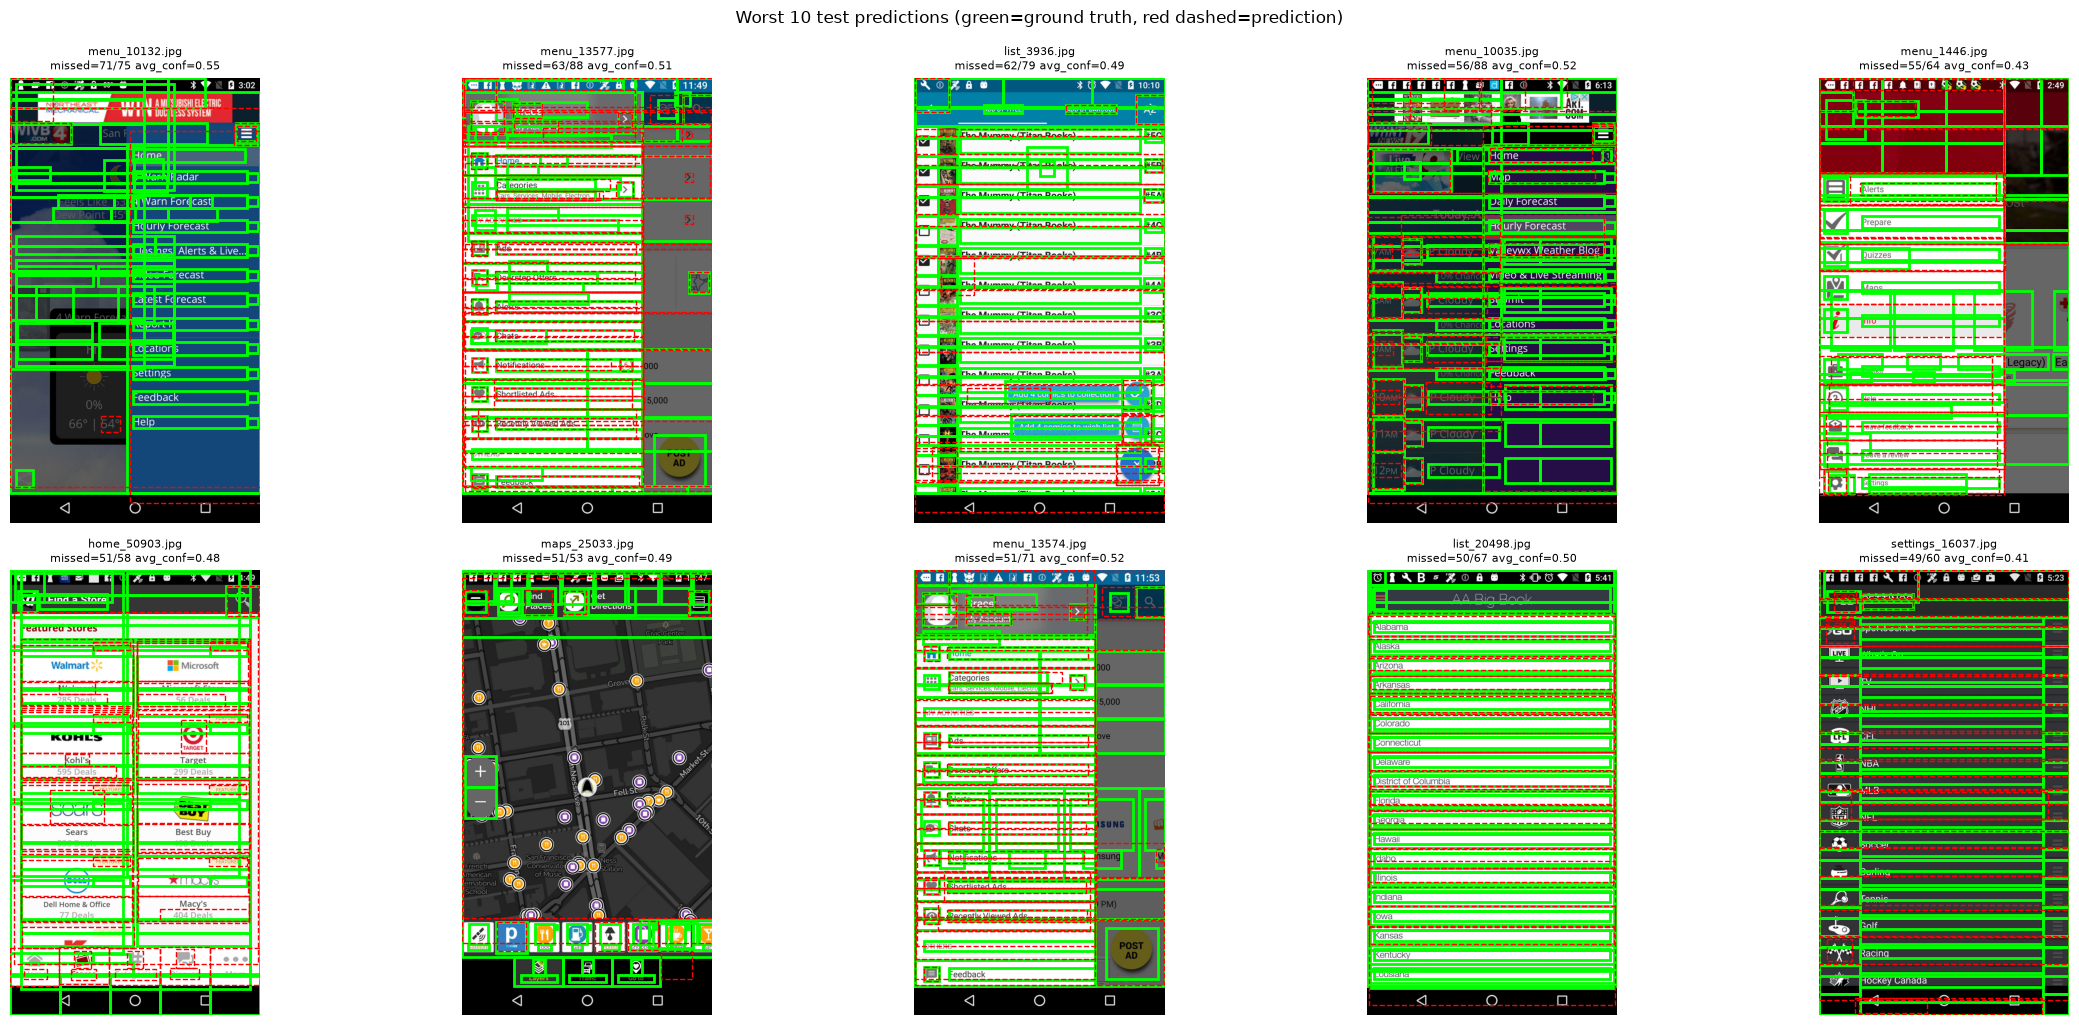

In [20]:
def iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    inter_w = max(0.0, min(ax2, bx2) - max(ax1, bx1))
    inter_h = max(0.0, min(ay2, by2) - max(ay1, by1))
    inter = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def load_yolo_gt_boxes(label_path, img_w, img_h):
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text(encoding="utf-8").splitlines():
        cls_idx, cx, cy, w, h = line.split()
        cx, cy, w, h = float(cx) * img_w, float(cy) * img_h, float(w) * img_w, float(h) * img_h
        boxes.append((int(cls_idx), (cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2)))
    return boxes


test_images_dir = CFG["yolo_dataset_dir"] / "images" / "test"
test_labels_dir = CFG["yolo_dataset_dir"] / "labels" / "test"
test_image_paths = sorted(test_images_dir.glob("*"))

scored = []
for image_path in test_image_paths:
    with Image.open(image_path) as im:
        img_w, img_h = im.size
    gt_boxes = load_yolo_gt_boxes(test_labels_dir / f"{image_path.stem}.txt", img_w, img_h)
    if not gt_boxes:
        continue

    pred = eval_model.predict(source=str(image_path), imgsz=CFG["imgsz"], verbose=False)[0]
    pred_boxes = [(int(b.cls[0]), tuple(float(v) for v in b.xyxy[0]), float(b.conf[0])) for b in pred.boxes]

    matched_confs = []
    n_missed = 0
    for gt_cls, gt_box in gt_boxes:
        candidates = [(iou(gt_box, pb), conf) for pcls, pb, conf in pred_boxes if pcls == gt_cls]
        best_iou, best_conf = max(candidates, default=(0.0, 0.0), key=lambda x: x[0])
        if best_iou >= 0.5:
            matched_confs.append(best_conf)
        else:
            n_missed += 1

    avg_conf = sum(matched_confs) / len(matched_confs) if matched_confs else 0.0
    scored.append({
        "image_path": image_path,
        "n_gt": len(gt_boxes),
        "n_missed": n_missed,
        "avg_matched_conf": avg_conf,
        "pred_boxes": pred_boxes,
        "gt_boxes": gt_boxes,
    })

scored.sort(key=lambda r: (-r["n_missed"], r["avg_matched_conf"]))
worst10 = scored[:10]

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
for ax, rec in zip(axes.ravel(), worst10):
    with Image.open(rec["image_path"]) as im:
        ax.imshow(im)
    for cls_idx, box in rec["gt_boxes"]:
        x1, y1, x2, y2 = box
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none"))
    for cls_idx, box, conf in rec["pred_boxes"]:
        x1, y1, x2, y2 = box
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor="red", facecolor="none", linestyle="--"))
    ax.set_title(f"{rec['image_path'].name}\nmissed={rec['n_missed']}/{rec['n_gt']} avg_conf={rec['avg_matched_conf']:.2f}", fontsize=8)
    ax.axis("off")
for ax in axes.ravel()[len(worst10):]:
    ax.axis("off")
plt.tight_layout()
plt.suptitle("Worst 10 test predictions (green=ground truth, red dashed=prediction)", y=1.02)
plt.show()

### Extra experiment: detector output vs XML node count (candidate unfocusable elements)

For each holdout screen, compare how many boxes the fine-tuned detector
finds against how many nodes survive our XML filtering pipeline. Detector
boxes with **no** XML counterpart nearby (no filtered XML node of the same
class within IoU ≥ 0.3) are flagged as candidates for "visually present but
not in the accessibility/focus tree" - i.e. elements a screen reader user
would never reach, which is exactly the kind of gap this whole detector was
built to catch. Skips gracefully if the holdout data isn't available.

In [21]:
if not CFG["rico_available"]:
    print("Skipping detector-vs-XML comparison: rico-holdout screenshots/xml not found under DATA_ROOT.")
else:
    comparison_rows = []
    rico_test_images = sorted((CFG["rico_yolo_dataset_dir"] / "images" / "test").glob("*"))

    for image_path in rico_test_images:
        stem = image_path.stem
        label_path = CFG["rico_yolo_dataset_dir"] / "labels" / "test" / f"{stem}.txt"
        with Image.open(image_path) as im:
            img_w, img_h = im.size
        xml_boxes = load_yolo_gt_boxes(label_path, img_w, img_h)

        pred = eval_model.predict(source=str(image_path), imgsz=CFG["imgsz"], verbose=False)[0]
        pred_boxes = [(int(b.cls[0]), tuple(float(v) for v in b.xyxy[0])) for b in pred.boxes]

        unmatched = []
        for cls_idx, box in pred_boxes:
            best_iou = max((iou(box, xb) for xcls, xb in xml_boxes if xcls == cls_idx), default=0.0)
            if best_iou < 0.3:
                unmatched.append((CFG["class_names"][cls_idx], box))

        comparison_rows.append({
            "screen": stem,
            "detector_count": len(pred_boxes),
            "xml_count": len(xml_boxes),
            "unmatched_detector_boxes": unmatched,
        })

    if comparison_rows:
        avg_detector = sum(r["detector_count"] for r in comparison_rows) / len(comparison_rows)
        avg_xml = sum(r["xml_count"] for r in comparison_rows) / len(comparison_rows)
        total_unmatched = sum(len(r["unmatched_detector_boxes"]) for r in comparison_rows)
        print(f"Screens compared: {len(comparison_rows)}")
        print(f"Avg detector boxes/screen: {avg_detector:.1f}   Avg filtered-XML nodes/screen: {avg_xml:.1f}")
        print(f"Total detector boxes with no XML counterpart (candidate unfocusable elements): {total_unmatched}")
        print()
        print("Example candidates (first 10):")
        shown = 0
        for r in comparison_rows:
            for cls_name, box in r["unmatched_detector_boxes"]:
                print(f"  {r['screen']}: class={cls_name} bbox={[round(v, 1) for v in box]}")
                shown += 1
                if shown >= 10:
                    break
            if shown >= 10:
                break
    else:
        print("No rico-holdout test images were built - nothing to compare.")

Screens compared: 1683
Avg detector boxes/screen: 15.4   Avg filtered-XML nodes/screen: 23.1
Total detector boxes with no XML counterpart (candidate unfocusable elements): 11624

Example candidates (first 10):
  chat_10103: class=button_icon_only bbox=[364.0, 1.4, 718.3, 137.4]
  chat_10103: class=button_icon_only bbox=[724.0, 1.4, 1076.7, 132.8]
  chat_10103: class=button_icon_only bbox=[2.8, 347.3, 985.7, 1853.7]
  chat_10103: class=text bbox=[77.7, 246.6, 283.0, 292.1]
  chat_10105: class=button_icon_only bbox=[0.0, 2.1, 540.8, 132.9]
  chat_10105: class=button_icon_only bbox=[539.8, 1.7, 1051.6, 126.1]
  chat_10105: class=text bbox=[727.3, 246.0, 895.3, 293.5]
  chat_10105: class=text bbox=[356.1, 519.5, 408.3, 578.9]
  chat_10105: class=button_icon_only bbox=[0.0, 1670.9, 1080.0, 1791.6]
  chat_10105: class=button_icon_only bbox=[940.3, 67.7, 1079.8, 202.8]


## 5. Export

Copy `best.pt` into a stable export location (both `OUTPUT_ROOT/export` and
the repo's `models/` dir), and write a small, dependency-light inference
module -
`src/yolo_ui_detector.py` - exposing `detect_ui(image_path)`. The main
auditor pipeline can import this directly for screenshot-only auditing:

```python
from src.yolo_ui_detector import detect_ui
detections = detect_ui("path/to/screenshot.png")
# -> [{"bbox": [x1, y1, x2, y2], "class": "button_labeled", "conf": 0.91}, ...]
```

In [22]:
CFG["export_dir"].mkdir(parents=True, exist_ok=True)
export_pt_path = CFG["export_dir"] / "yolo_ui_detector_best.pt"
shutil.copy2(best_pt, export_pt_path)
print(f"Copied best weights to {export_pt_path}")

repo_models_dir = CFG["repo_root"] / "models"
repo_models_dir.mkdir(parents=True, exist_ok=True)
repo_pt_path = repo_models_dir / "yolo_ui_detector_best.pt"
shutil.copy2(best_pt, repo_pt_path)
print(f"Copied best weights to {repo_pt_path}")

module_source = '''"""Screenshot-only Android UI element detector (YOLO, fine-tuned).

Generated by notebooks/train_yolo_ui_detector.ipynb. Used when no XML view
hierarchy is available for a screen, so the accessibility auditor can still
locate and classify UI elements from pixels alone.
"""
from __future__ import annotations

from pathlib import Path

from ultralytics import YOLO

DEFAULT_WEIGHTS = Path(__file__).resolve().parents[1] / "models" / "yolo_ui_detector_best.pt"

_model_cache: dict[str, YOLO] = {}


def _get_model(weights_path: str | Path) -> YOLO:
    key = str(weights_path)
    if key not in _model_cache:
        _model_cache[key] = YOLO(key)
    return _model_cache[key]


def detect_ui(image_path: str | Path, weights_path: str | Path = DEFAULT_WEIGHTS, conf: float = 0.25) -> list[dict]:
    """Run the fine-tuned detector on one screenshot.

    Returns a list of {"bbox": [x1, y1, x2, y2], "class": str, "conf": float}
    dicts, one per detected UI element, in the original image\'s pixel space.
    """
    model = _get_model(weights_path)
    result = model.predict(source=str(image_path), conf=conf, verbose=False)[0]
    names = result.names
    detections = []
    for box in result.boxes:
        x1, y1, x2, y2 = (float(v) for v in box.xyxy[0])
        detections.append({
            "bbox": [x1, y1, x2, y2],
            "class": names[int(box.cls[0])],
            "conf": float(box.conf[0]),
        })
    return detections
'''

module_path = CFG["repo_root"] / "src" / "yolo_ui_detector.py"
module_path.write_text(module_source, encoding="utf-8")
print(f"Wrote {module_path}")
print()
print("Done. detect_ui() is importable from src.yolo_ui_detector once models/yolo_ui_detector_best.pt is present.")

Copied best weights to d:\New folder\agentic-accessibility-auditor\runs\yolo_ui_detector\export\yolo_ui_detector_best.pt
Copied best weights to d:\New folder\agentic-accessibility-auditor\models\yolo_ui_detector_best.pt
Wrote d:\New folder\agentic-accessibility-auditor\src\yolo_ui_detector.py

Done. detect_ui() is importable from src.yolo_ui_detector once models/yolo_ui_detector_best.pt is present.


## Next steps

- Flip `LOCAL_MODE = False` and re-run on your GPU machine for the real
  training run (60 epochs on the full split).
- Before that, make sure `data-masc` and `data-rico-holdout` (screenshots +
  xml, not just the manifests) are present under this repo's `data/` dir.
- Once training finishes, `src/yolo_ui_detector.detect_ui()` is ready to
  wire into the main auditor pipeline (`src/agent.py` /
  `src/screenshot_analysis.py`-equivalent) as the screenshot-only fallback
  path when no XML view hierarchy is supplied.